In [1]:
import arcgis
import fastai
import torch

In [4]:
%env CUDA_VISIBLE_DEVICES=0

env: CUDA_VISIBLE_DEVICES=0


In [8]:
from arcgis.learn import prepare_data, SingleShotDetector
from fastai.vision.data import ImageDataBunch

In [9]:
rgb_path = r'/mnt/Raster/Data/testdata/extracted_data/object_detection_data/palm-tree-256'

In [10]:
data = prepare_data(rgb_path, batch_size=4, class_mapping={'0': 'pool'}, transforms=False)

In [11]:
data

ImageDataBunch;

Train: LabelList (144 items)
x: ObjectDetectionItemList
Image (3, 448, 448),Image (3, 448, 448),Image (3, 448, 448),Image (3, 448, 448),Image (3, 448, 448)
y: ObjectDetectionCategoryList
ImageBBox (448, 448),ImageBBox (448, 448),ImageBBox (448, 448),ImageBBox (448, 448),ImageBBox (448, 448)
Path: \\ndhfs1\Raster\Data\testdata\extracted_data\object_detection_data\palm-tree-256\images;

Valid: LabelList (16 items)
x: ObjectDetectionItemList
Image (3, 448, 448),Image (3, 448, 448),Image (3, 448, 448),Image (3, 448, 448),Image (3, 448, 448)
y: ObjectDetectionCategoryList
ImageBBox (448, 448),ImageBBox (448, 448),ImageBBox (448, 448),ImageBBox (448, 448),ImageBBox (448, 448)
Path: \\ndhfs1\Raster\Data\testdata\extracted_data\object_detection_data\palm-tree-256\images;

Test: None

In [12]:
assert isinstance(data, ImageDataBunch)

In [13]:
data.class_mapping

{1: 'Palm', 2: 'House'}

In [14]:
assert isinstance(data.class_mapping, dict)

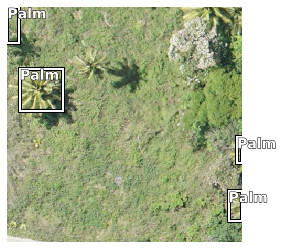

In [15]:
data.show_batch(rows=1)

In [16]:
model = SingleShotDetector(data)

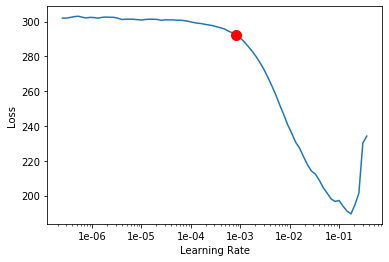

0.0008317637711026709

In [43]:
model.lr_find()

In [44]:
model.fit(10)

epoch,train_loss,valid_loss,time
0,278.126404,228.359985,01:00
1,179.026703,51.872112,01:01
2,103.556351,41.122459,00:58
3,68.349075,40.433952,01:00
4,48.482952,39.961784,01:00
5,36.103638,39.533806,01:03
6,27.673582,40.286755,01:09
7,21.802757,41.609482,01:02
8,18.148056,41.778141,01:01
9,15.830818,41.545666,01:20


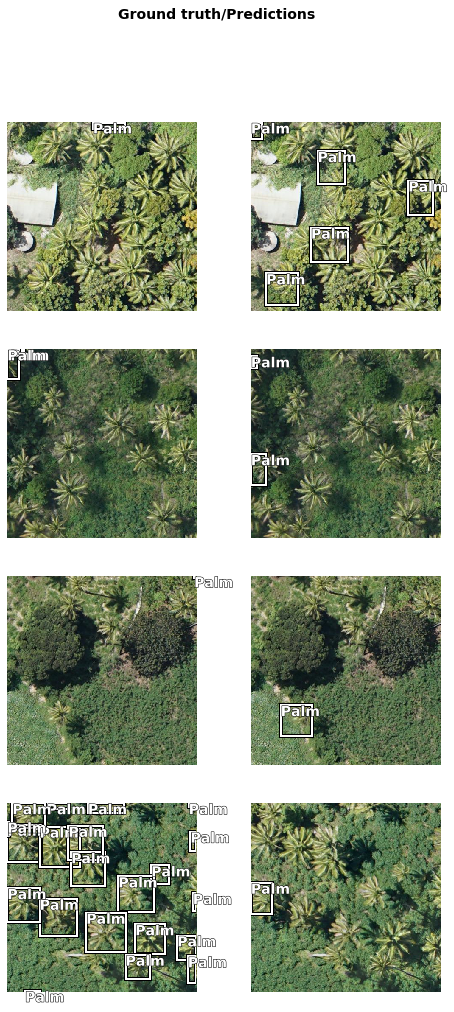

In [45]:
model.show_results()

In [12]:
model.save(r'/mnt/Raster/Data/testdata/extracted_data/object_detection_data/palm-tree-256/test-object-det')

WindowsPath('//ndhfs1/Raster/Data/testdata/extracted_data/object_detection_data/palm-tree-256/models/fastTest')

In [18]:
score = model.average_precision_score()